🎬 ANALISI DEI BIGLIETTI VENDUTI STIMATI DAGLI INCASSI E PREZZI MEDI

1. LETTURA DEL FILE DEGLI INCASSI TOTALI...
----------------------------------------
Prima riga del file IncassiTot.csv:
          Nome del film  Unnamed: 1  Unnamed: 2 Incassi (in euro)  Unnamed: 4
0              Ne Zha 2         NaN         NaN     1,916,284,213         NaN
1            Zootopia 2         NaN         NaN     1,507,669,984         NaN
2  Avatar: Fire and Ash         NaN         NaN     1,200,040,219         NaN
3         Lilo & Stitch         NaN         NaN       880,226,581         NaN
4     A Minecraft Movie         NaN         NaN       812,608,871         NaN

Colonne trovate: ['Nome del film', 'Incassi_euro']

Primi dati:
          Nome del film   Incassi_euro
0              Ne Zha 2  1,916,284,213
1            Zootopia 2  1,507,669,984
2  Avatar: Fire and Ash  1,200,040,219
3         Lilo & Stitch    880,226,581
4     A Minecraft Movie    812,608,871

✓ Incassi totali: 10 film processati

Inca

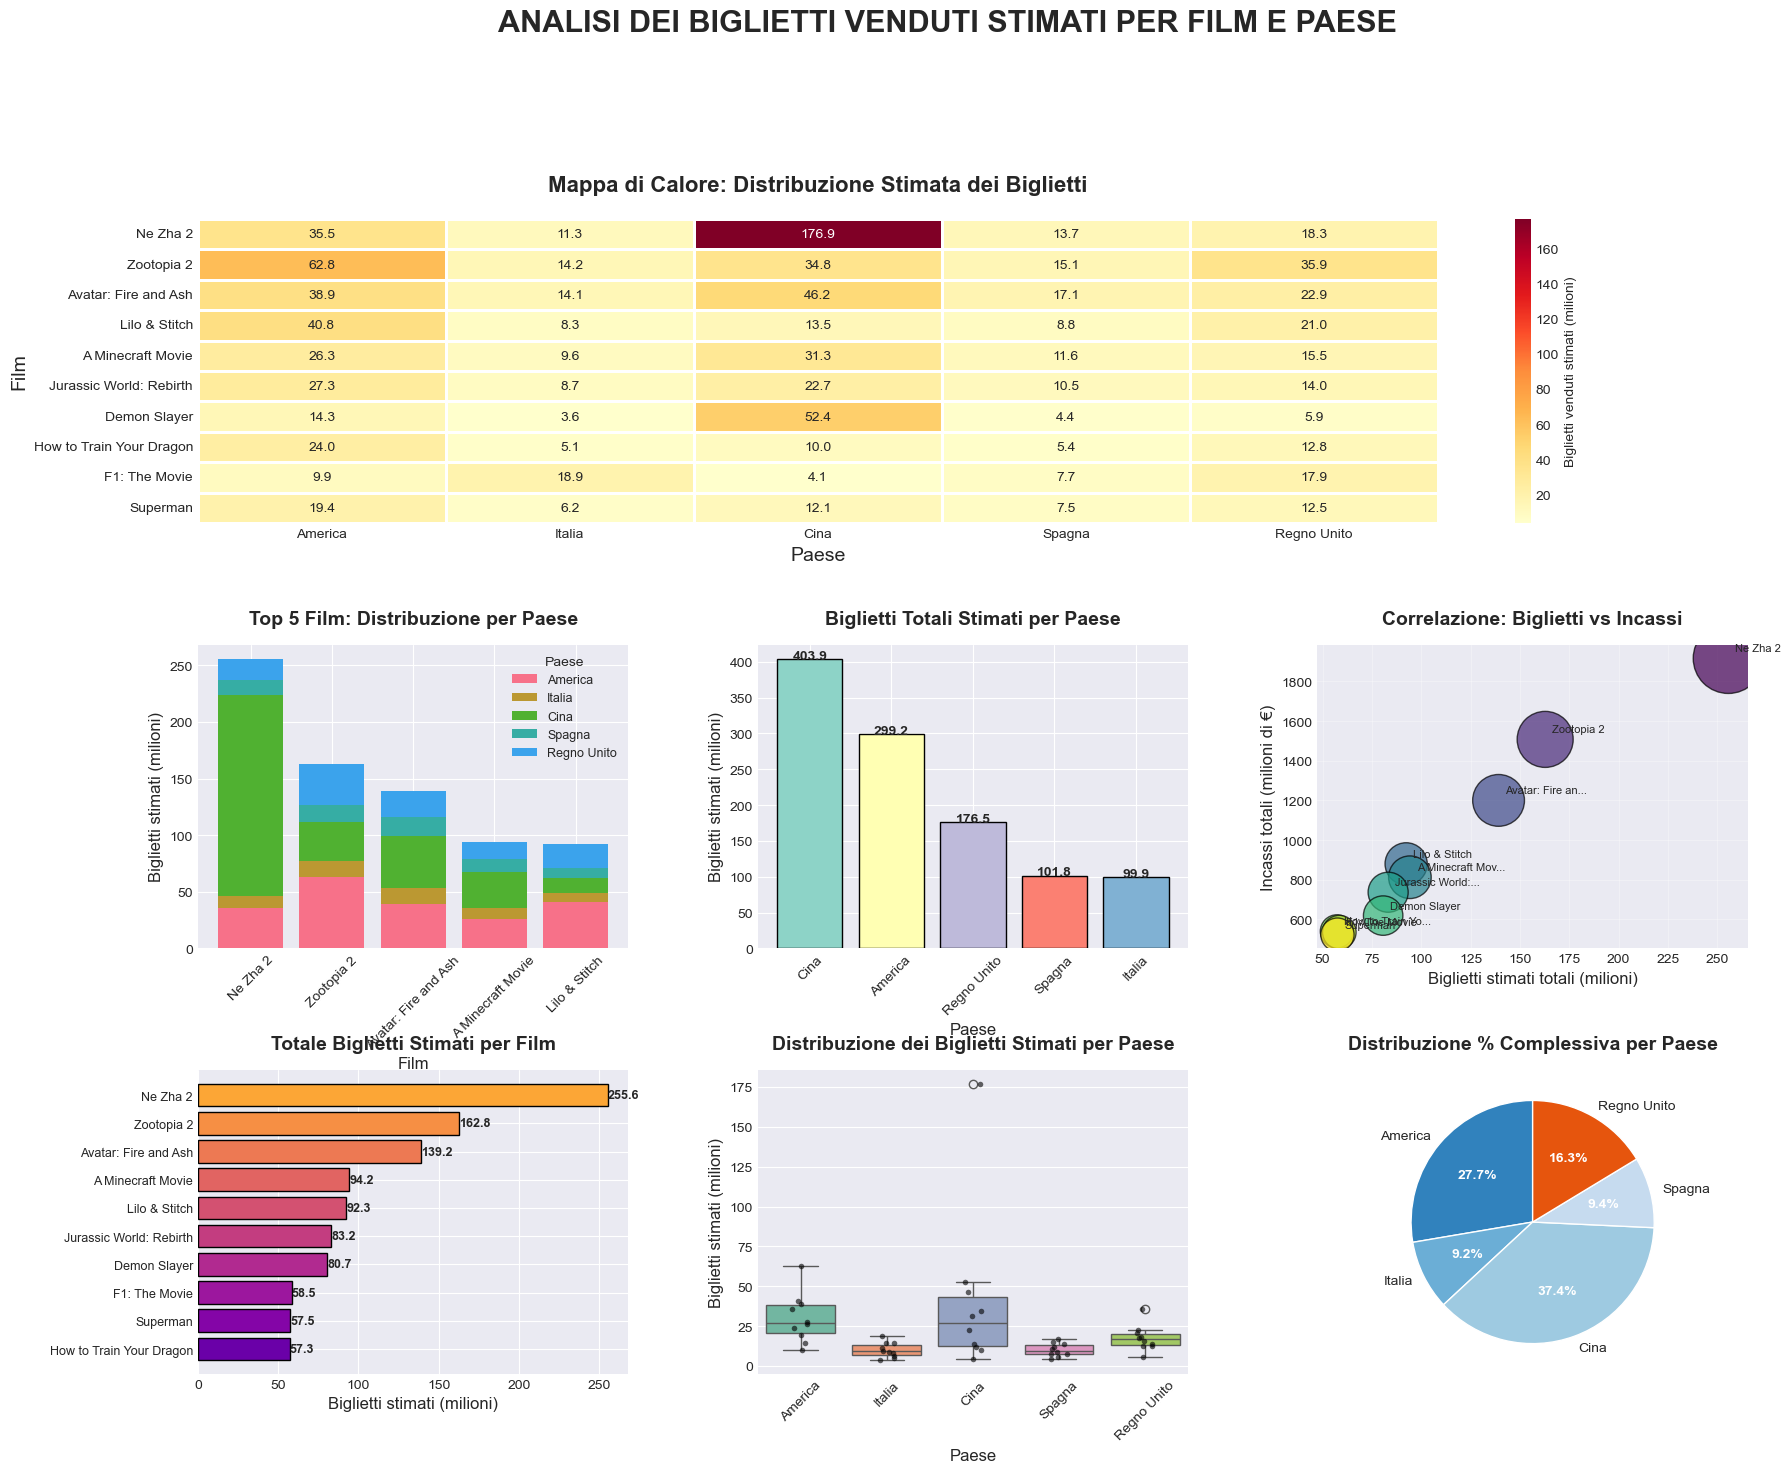



5. VISUALIZZAZIONI AGGIUNTIVE E ANALISI DETTAGLIATA


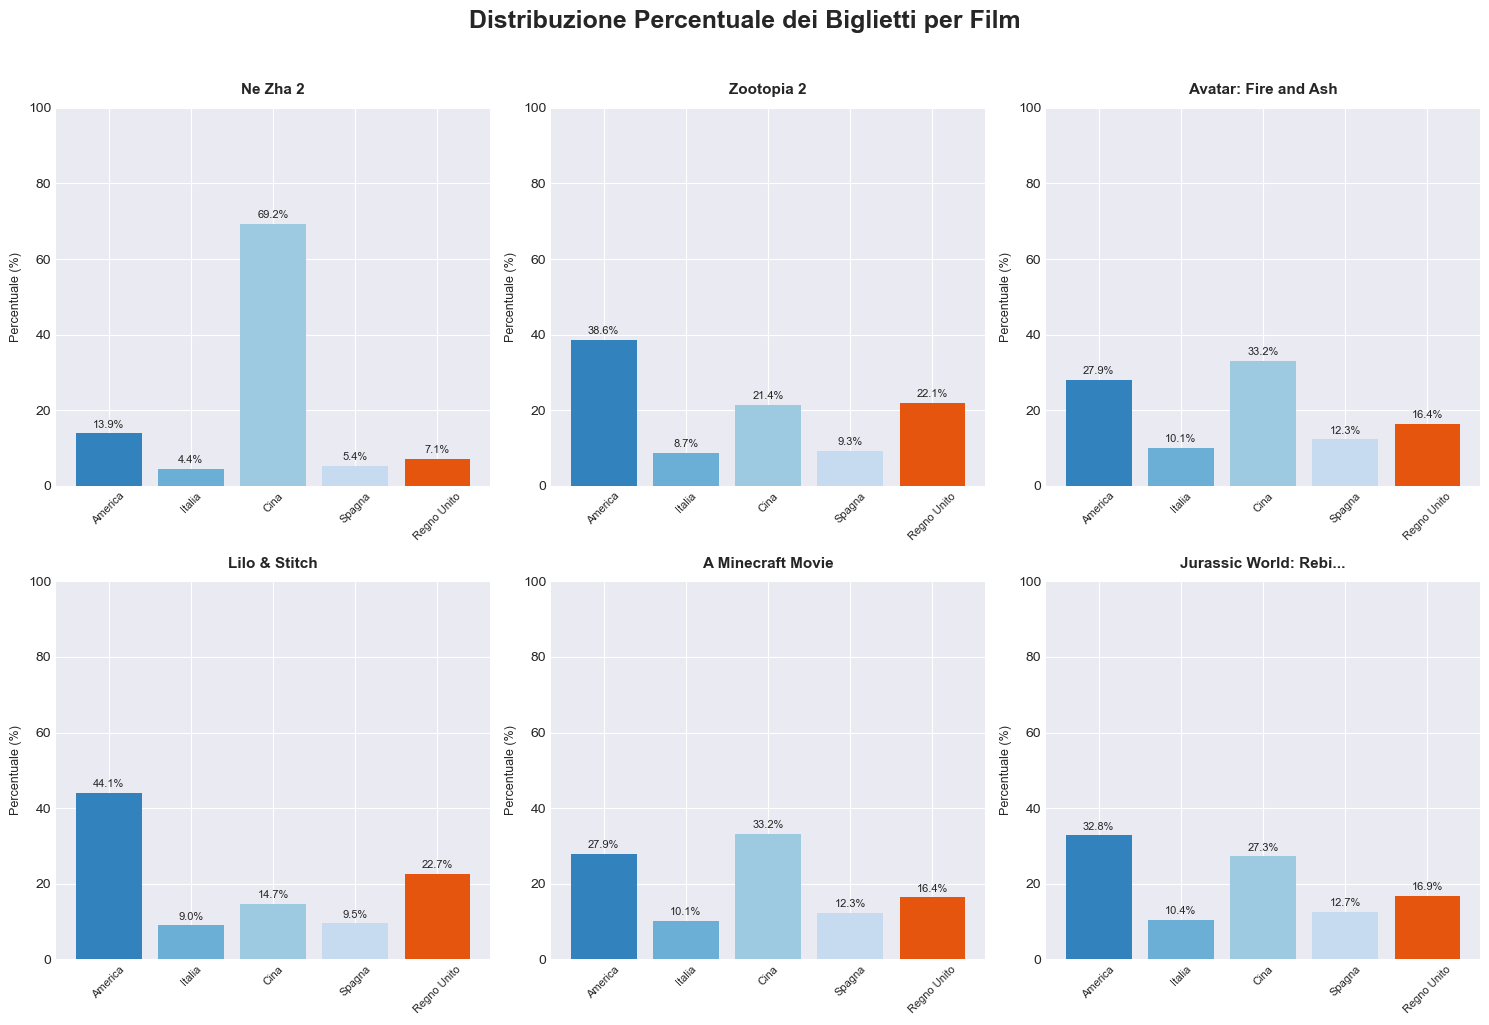

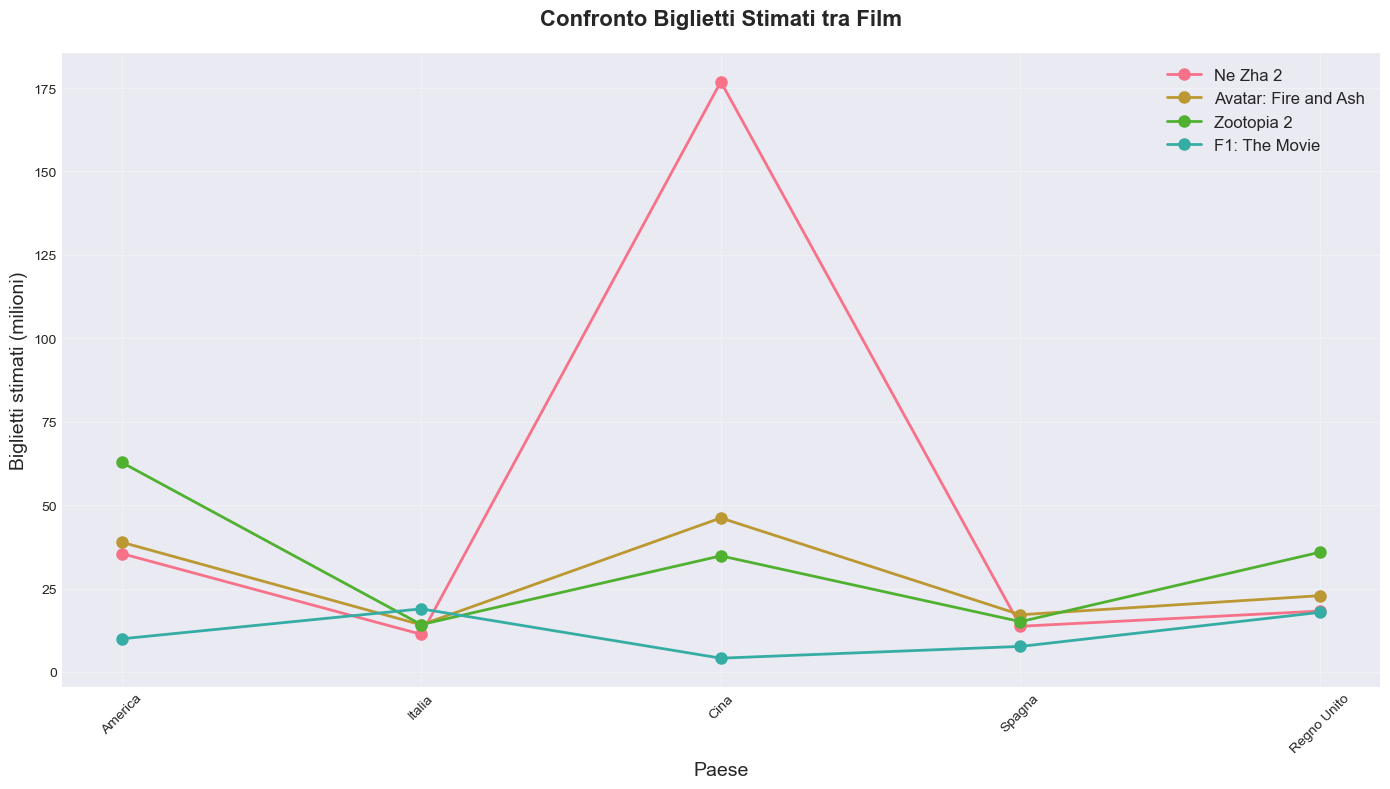



6. ANALISI STATISTICA E INSIGHTS

1. STATISTICHE DESCRITTIVE PER PAESE:
--------------------------------------------------
       America  Italia    Cina  Spagna  Regno Unito
count    10.00   10.00   10.00   10.00        10.00
mean     29.92    9.99   40.39   10.18        17.65
std      15.35    4.71   50.55    4.20         8.01
min       9.92    3.64    4.12    4.42         5.90
25%      20.52    6.69   12.44    7.52        13.15
50%      26.82    9.12   26.97    9.67        16.67
75%      38.04   13.41   43.31   13.17        20.28
max      62.82   18.91  176.89   17.14        35.90


2. CLASSIFICHE:
--------------------------------------------------

Top 5 Film per biglietti stimati totali:
  1. Ne Zha 2: 255.6 milioni di biglietti
  2. Zootopia 2: 162.8 milioni di biglietti
  3. Avatar: Fire and Ash: 139.2 milioni di biglietti
  4. A Minecraft Movie: 94.2 milioni di biglietti
  5. Lilo & Stitch: 92.3 milioni di biglietti


Paesi ordinati per biglietti stimati totali:
  1. Cina: 40

In [2]:
# Import delle librerie necessarie
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configurazione dello stile
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# 1. LETTURA E PROCESSAMENTO DEI DATASET
print("🎬 ANALISI DEI BIGLIETTI VENDUTI STIMATI DAGLI INCASSI E PREZZI MEDI")
print("=" * 90)

# 1.1 Leggi il file degli incassi totali
print("\n1. LETTURA DEL FILE DEGLI INCASSI TOTALI...")
print("-" * 40)

try:
    df_incassi = pd.read_csv('IncassiTot.csv', sep=',', engine='python')
except:
    # Prova con separatore differente
    df_incassi = pd.read_csv('IncassiTot.csv', sep=';', engine='python')

print("Prima riga del file IncassiTot.csv:")
print(df_incassi.head())

# Pulizia del DataFrame degli incassi
df_incassi = df_incassi.dropna(axis=1, how='all')
df_incassi.columns = [col.strip() for col in df_incassi.columns]

# Trova la colonna del nome del film (di solito la prima)
nome_film_col = df_incassi.columns[0]
df_incassi = df_incassi.rename(columns={nome_film_col: 'Nome del film'})

# Cerca la colonna degli incassi
incassi_col = None
for col in df_incassi.columns:
    if 'incassi' in str(col).lower() or 'euro' in str(col).lower():
        incassi_col = col
        break

if incassi_col:
    df_incassi = df_incassi[['Nome del film', incassi_col]]
    df_incassi = df_incassi.rename(columns={incassi_col: 'Incassi_euro'})
else:
    # Prendi la prima colonna numerica dopo il nome
    numeric_cols = df_incassi.select_dtypes(include=[np.number]).columns
    if len(numeric_cols) > 0:
        incassi_col = numeric_cols[0]
        df_incassi = df_incassi[['Nome del film', incassi_col]]
        df_incassi = df_incassi.rename(columns={incassi_col: 'Incassi_euro'})
    else:
        # Se non ci sono colonne numeriche, usa la seconda colonna
        df_incassi = df_incassi.iloc[:, [0, 1]]
        df_incassi.columns = ['Nome del film', 'Incassi_euro']

print(f"\nColonne trovate: {df_incassi.columns.tolist()}")
print(f"\nPrimi dati:")
print(df_incassi.head())

# Pulisci e converti gli incassi
def clean_incassi(value):
    if pd.isna(value):
        return 0.0
    if isinstance(value, (int, float, np.integer, np.floating)):
        return float(value)
    
    value_str = str(value).strip()
    
    # Rimuovi caratteri non numerici tranne punti e virgole
    value_str = value_str.replace('"', '').replace("'", '').replace(' ', '')
    
    # Gestione di formati numerici
    if ',' in value_str and '.' in value_str:
        # Formato: "1,916,284,213.00" (punti separatori migliaia, virgola decimale)
        # Invertiamo: trattiamo la virgola come decimale
        value_str = value_str.replace('.', '').replace(',', '.')
    elif ',' in value_str and value_str.count(',') == 1:
        # Formato: "1916284213,00" (virgola come separatore decimale europeo)
        value_str = value_str.replace(',', '.')
    elif ',' in value_str:
        # Formato: "1,916,284,213" (virgole come separatori migliaia)
        value_str = value_str.replace(',', '')
    
    try:
        return float(value_str)
    except:
        print(f"Warning: Non posso convertire '{value}' in numero, usando 0")
        return 0.0

df_incassi['Incassi_euro'] = df_incassi['Incassi_euro'].apply(clean_incassi)
df_incassi.set_index('Nome del film', inplace=True)

print(f"\n✓ Incassi totali: {len(df_incassi)} film processati")
print("\nIncassi per film (in euro):")
for film, incasso in df_incassi['Incassi_euro'].items():
    print(f"  • {film}: {incasso:,.0f} €")

# 1.2 Leggi il file dei prezzi medi
print("\n\n2. LETTURA DEL FILE DEI PREZZI MEDI...")
print("-" * 40)

try:
    df_prezzi = pd.read_csv('PrezzoMedioTickets.csv', sep=',', engine='python')
except:
    df_prezzi = pd.read_csv('PrezzoMedioTickets.csv', sep=';', engine='python')

print("Dati prezzi medi:")
print(df_prezzi)

# Pulizia dei prezzi medi
def clean_prezzo(value):
    if pd.isna(value):
        return 0.0
    if isinstance(value, (int, float, np.integer, np.floating)):
        return float(value)
    
    value_str = str(value).strip().lower()
    
    # Rimuovi 'eur', 'euro', '€' e spazi
    value_str = value_str.replace('eur', '').replace('euro', '').replace('€', '').replace(' ', '')
    
    # Sostituisci la virgola con il punto se presente
    value_str = value_str.replace(',', '.')
    
    try:
        return float(value_str)
    except:
        print(f"Warning: Non posso convertire prezzo '{value}', usando 0")
        return 0.0

# Applica la pulizia a tutte le colonne
for col in df_prezzi.columns:
    df_prezzi[col] = df_prezzi[col].apply(clean_prezzo)

# Crea un Series con i prezzi medi per paese
prezzi_medi = df_prezzi.iloc[0]
print("\nPrezzi medi dei biglietti per paese:")
for paese, prezzo in prezzi_medi.items():
    print(f"  • {paese}: {prezzo:.1f} €")

# 2. CALCOLO DEI BIGLIETTI VENDUTI STIMATI
print("\n\n3. CALCOLO DEI BIGLIETTI VENDUTI STIMATI...")
print("=" * 90)

# Definisci profili di distribuzione per tipo di film
profili_distribuzione = {
    # Film con forte appeal in Cina
    'Ne Zha 2': {'Cina': 0.60, 'America': 0.20, 'Regno Unito': 0.10, 'Italia': 0.05, 'Spagna': 0.05},
    'Demon Slayer': {'Cina': 0.55, 'America': 0.25, 'Regno Unito': 0.10, 'Italia': 0.05, 'Spagna': 0.05},
    
    # Film con appeal globale
    'Avatar: Fire and Ash': {'America': 0.35, 'Cina': 0.25, 'Regno Unito': 0.20, 'Italia': 0.10, 'Spagna': 0.10},
    'Jurassic World: Rebirth': {'America': 0.40, 'Cina': 0.20, 'Regno Unito': 0.20, 'Italia': 0.10, 'Spagna': 0.10},
    
    # Film con appeal occidentale
    'Zootopia 2': {'America': 0.45, 'Regno Unito': 0.25, 'Cina': 0.15, 'Italia': 0.08, 'Spagna': 0.07},
    'Lilo & Stitch': {'America': 0.50, 'Regno Unito': 0.25, 'Cina': 0.10, 'Italia': 0.08, 'Spagna': 0.07},
    'How to Train Your Dragon': {'America': 0.48, 'Regno Unito': 0.25, 'Cina': 0.12, 'Italia': 0.08, 'Spagna': 0.07},
    
    # Film con appeal misto
    'A Minecraft Movie': {'America': 0.35, 'Regno Unito': 0.20, 'Cina': 0.25, 'Italia': 0.10, 'Spagna': 0.10},
    'Superman': {'America': 0.40, 'Regno Unito': 0.25, 'Cina': 0.15, 'Italia': 0.10, 'Spagna': 0.10},
    
    # Film di nicchia
    'F1: The Movie': {'Regno Unito': 0.35, 'Italia': 0.30, 'America': 0.20, 'Spagna': 0.10, 'Cina': 0.05}
}

# Calcola i biglietti stimati
df_biglietti_stimati = pd.DataFrame(index=df_incassi.index, columns=prezzi_medi.index)

for film in df_incassi.index:
    incasso_totale = df_incassi.loc[film, 'Incassi_euro']
    
    # Normalizza il nome del film per la ricerca nel dizionario
    film_clean = str(film).strip()
    
    # Usa il profilo specifico se disponibile
    if film_clean in profili_distribuzione:
        profilo = profili_distribuzione[film_clean]
    else:
        # Cerca corrispondenze parziali
        profilo_trovato = None
        for key in profili_distribuzione.keys():
            if key.lower() in film_clean.lower() or film_clean.lower() in key.lower():
                profilo_trovato = profili_distribuzione[key]
                break
        
        if profilo_trovato:
            profilo = profilo_trovato
        else:
            # Profilo generico per film non specificati
            profilo = {'America': 0.35, 'Cina': 0.25, 'Regno Unito': 0.20, 'Italia': 0.10, 'Spagna': 0.10}
    
    for paese in prezzi_medi.index:
        # Incasso stimato per il paese
        percentuale = profilo.get(paese, 0)
        incasso_paese = incasso_totale * percentuale
        
        # Biglietti stimati = incasso / prezzo medio
        prezzo_medio = prezzi_medi[paese]
        biglietti_stimati = incasso_paese / prezzo_medio if prezzo_medio > 0 else 0
        
        # Converti in milioni per leggibilità
        df_biglietti_stimati.loc[film, paese] = biglietti_stimati / 1_000_000

# Converti tutti i valori in float
df_biglietti_stimati = df_biglietti_stimati.astype(float)

print("\nBiglietti venduti stimati (in milioni):")
print(df_biglietti_stimati.round(2))

# 3. VISUALIZZAZIONI DEI RISULTATI
print("\n\n4. VISUALIZZAZIONI DEI BIGLIETTI VENDUTI STIMATI")
print("=" * 90)

# Usiamo il DataFrame dei biglietti stimati
df_viz = df_biglietti_stimati

# 3.1 Creazione della figura principale
fig = plt.figure(figsize=(20, 15))
fig.suptitle('ANALISI DEI BIGLIETTI VENDUTI STIMATI PER FILM E PAESE', 
             fontsize=22, fontweight='bold', y=1.02)

# Definizione della griglia
gs = fig.add_gridspec(3, 3, hspace=0.4, wspace=0.3)

# 3.1.1 Heatmap principale
ax1 = fig.add_subplot(gs[0, :])
# Assicurati che i dati siano numerici
heatmap_data = df_viz.astype(float)
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlOrRd", 
            linewidths=1, linecolor='white', ax=ax1,
            cbar_kws={'label': 'Biglietti venduti stimati (milioni)'})
ax1.set_title('Mappa di Calore: Distribuzione Stimata dei Biglietti', 
              fontsize=16, fontweight='bold', pad=20)
ax1.set_xlabel('Paese', fontsize=14)
ax1.set_ylabel('Film', fontsize=14)
ax1.tick_params(axis='x', rotation=0)
ax1.tick_params(axis='y', rotation=0)

# 3.1.2 Grafico a barre impilate per paese (Top 5 film)
ax2 = fig.add_subplot(gs[1, 0])
# Prendi i top 5 film per visualizzazione
top_5_film = df_viz.sum(axis=1).nlargest(5).index
df_top5 = df_viz.loc[top_5_film].astype(float)

df_top5.plot(kind='bar', stacked=True, ax=ax2, width=0.8)
ax2.set_title('Top 5 Film: Distribuzione per Paese', 
              fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Film', fontsize=12)
ax2.set_ylabel('Biglietti stimati (milioni)', fontsize=12)
ax2.tick_params(axis='x', rotation=45)
ax2.legend(title='Paese', fontsize=9, title_fontsize=10)

# 3.1.3 Grafico a barre per totali per paese
ax3 = fig.add_subplot(gs[1, 1])
totali_paese = df_viz.sum().sort_values(ascending=False)
colors = plt.cm.Set3(np.arange(len(totali_paese)))
bars = ax3.bar(totali_paese.index, totali_paese.values, color=colors, edgecolor='black')
ax3.set_title('Biglietti Totali Stimati per Paese', 
              fontsize=14, fontweight='bold', pad=15)
ax3.set_xlabel('Paese', fontsize=12)
ax3.set_ylabel('Biglietti stimati (milioni)', fontsize=12)
ax3.tick_params(axis='x', rotation=45)

# Aggiungi valori sulle barre
for bar, value in zip(bars, totali_paese.values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{value:.1f}', ha='center', fontsize=10, fontweight='bold')

# 3.1.4 Grafico a dispersione: Incassi vs Biglietti Stimati
ax4 = fig.add_subplot(gs[1, 2])
totali_film = df_viz.sum(axis=1)
incassi_film = df_incassi['Incassi_euro'] / 1_000_000  # Converti in milioni di euro

scatter = ax4.scatter(totali_film.values, incassi_film.values,
                     s=totali_film.values * 10,  # Dimensione proporzionale ai biglietti
                     alpha=0.7,
                     c=range(len(totali_film)),
                     cmap='viridis',
                     edgecolors='black')

# Aggiungi etichette dei film
for i, film in enumerate(totali_film.index):
    ax4.annotate(film[:15] + ('...' if len(film) > 15 else ''),
                (totali_film[i], incassi_film[i]),
                xytext=(5, 5), textcoords='offset points',
                fontsize=8)

ax4.set_title('Correlazione: Biglietti vs Incassi', 
              fontsize=14, fontweight='bold', pad=15)
ax4.set_xlabel('Biglietti stimati totali (milioni)', fontsize=12)
ax4.set_ylabel('Incassi totali (milioni di €)', fontsize=12)
ax4.grid(True, alpha=0.3)

# 3.1.5 Grafico a barre orizzontali per film (Top 10)
ax5 = fig.add_subplot(gs[2, 0])
totali_per_film = df_viz.sum(axis=1).sort_values(ascending=True)
colors_bars = plt.cm.plasma(np.linspace(0.2, 0.8, len(totali_per_film)))

bars = ax5.barh(range(len(totali_per_film)), totali_per_film.values, 
                color=colors_bars, edgecolor='black')
ax5.set_title('Totale Biglietti Stimati per Film', 
              fontsize=14, fontweight='bold', pad=15)
ax5.set_xlabel('Biglietti stimati (milioni)', fontsize=12)
ax5.set_yticks(range(len(totali_per_film)))
ax5.set_yticklabels(totali_per_film.index, fontsize=9)

# Aggiungi valori sulle barre
for i, (bar, value) in enumerate(zip(bars, totali_per_film.values)):
    ax5.text(value + 0.1, i, f'{value:.1f}', va='center', fontsize=9, fontweight='bold')

# 3.1.6 Boxplot della distribuzione per paese
ax6 = fig.add_subplot(gs[2, 1])
# Prepara i dati in formato lungo per seaborn
df_melted = df_viz.reset_index().melt(id_vars='Nome del film', 
                                      var_name='Paese', 
                                      value_name='Biglietti_Stimati')
sns.boxplot(data=df_melted, x='Paese', y='Biglietti_Stimati', ax=ax6, palette='Set2')
sns.stripplot(data=df_melted, x='Paese', y='Biglietti_Stimati', 
              ax=ax6, color='black', size=4, jitter=True, alpha=0.6)
ax6.set_title('Distribuzione dei Biglietti Stimati per Paese', 
              fontsize=14, fontweight='bold', pad=15)
ax6.set_xlabel('Paese', fontsize=12)
ax6.set_ylabel('Biglietti stimati (milioni)', fontsize=12)
ax6.tick_params(axis='x', rotation=45)

# 3.1.7 Grafico a torta per distribuzione complessiva
ax7 = fig.add_subplot(gs[2, 2])
totali_paese_perc = df_viz.sum()
colors_pie = plt.cm.tab20c(np.arange(len(totali_paese_perc)))
wedges, texts, autotexts = ax7.pie(totali_paese_perc.values, 
                                   labels=totali_paese_perc.index,
                                   autopct='%1.1f%%',
                                   colors=colors_pie,
                                   startangle=90,
                                   wedgeprops={'edgecolor': 'white', 'linewidth': 1})
ax7.set_title('Distribuzione % Complessiva per Paese', 
              fontsize=14, fontweight='bold', pad=15)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

plt.tight_layout()
plt.show()

# 4. VISUALIZZAZIONI AGGIUNTIVE
print("\n\n5. VISUALIZZAZIONI AGGIUNTIVE E ANALISI DETTAGLIATA")
print("=" * 90)

# 4.1 Grafico delle percentuali di distribuzione per film
fig2, axes2 = plt.subplots(2, 3, figsize=(15, 10))
fig2.suptitle('Distribuzione Percentuale dei Biglietti per Film', 
              fontsize=18, fontweight='bold', y=1.02)

# Seleziona i primi 6 film per visualizzazione
film_selezionati = df_viz.index[:6] if len(df_viz) >= 6 else df_viz.index

for idx, film in enumerate(film_selezionati):
    row = idx // 3
    col = idx % 3
    ax = axes2[row, col]
    
    # Calcola le percentuali
    valori = df_viz.loc[film]
    totale = valori.sum()
    percentuali = (valori / totale * 100) if totale > 0 else 0
    
    # Grafico a barre delle percentuali
    bars = ax.bar(percentuali.index, percentuali.values, 
                  color=plt.cm.tab20c(np.arange(len(percentuali))))
    ax.set_title(f'{film[:20]}' + ('...' if len(film) > 20 else ''), 
                 fontsize=11, fontweight='bold', pad=10)
    ax.set_ylabel('Percentuale (%)', fontsize=9)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.set_ylim(0, 100)
    
    # Aggiungi i valori percentuali sulle barre
    for bar, perc in zip(bars, percentuali.values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 1,
               f'{perc:.1f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# 4.2 Grafico a linee per confronto tra film
fig3, ax3 = plt.subplots(figsize=(14, 8))

# Seleziona alcuni film rappresentativi
film_rappresentativi = ['Ne Zha 2', 'Avatar: Fire and Ash', 'Zootopia 2', 'F1: The Movie']

for film in film_rappresentativi:
    if film in df_viz.index:
        ax3.plot(df_viz.columns, df_viz.loc[film], marker='o', linewidth=2, markersize=8, label=film)

ax3.set_title('Confronto Biglietti Stimati tra Film', 
              fontsize=16, fontweight='bold', pad=20)
ax3.set_xlabel('Paese', fontsize=14)
ax3.set_ylabel('Biglietti stimati (milioni)', fontsize=14)
ax3.legend(fontsize=12)
ax3.grid(True, alpha=0.3)
ax3.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# 5. ANALISI STATISTICA E INSIGHTS
print("\n\n6. ANALISI STATISTICA E INSIGHTS")
print("=" * 90)

# 5.1 Calcola statistiche descrittive
print("\n1. STATISTICHE DESCRITTIVE PER PAESE:")
print("-" * 50)
stats_paese = df_viz.describe()
print(stats_paese.round(2))

print("\n\n2. CLASSIFICHE:")
print("-" * 50)

# Film con più biglietti stimati
print("\nTop 5 Film per biglietti stimati totali:")
top_film = df_viz.sum(axis=1).nlargest(5)
for i, (film, totale) in enumerate(top_film.items(), 1):
    print(f"  {i}. {film}: {totale:.1f} milioni di biglietti")

# Paesi con più biglietti stimati
print("\n\nPaesi ordinati per biglietti stimati totali:")
top_paesi = df_viz.sum().sort_values(ascending=False)
for i, (paese, totale) in enumerate(top_paesi.items(), 1):
    print(f"  {i}. {paese}: {totale:.1f} milioni di biglietti")

# 5.2 Calcola il prezzo medio ponderato
print("\n\n3. ANALISI DEI PREZZI E VALORI:")
print("-" * 50)

# Calcola il prezzo medio effettivo per i primi 3 film
for film in df_viz.index[:3]:
    incasso_totale = df_incassi.loc[film, 'Incassi_euro']
    biglietti_totali = df_viz.loc[film].sum() * 1_000_000  # Converti da milioni a unità
    
    if biglietti_totali > 0:
        prezzo_medio_effettivo = incasso_totale / biglietti_totali
        prezzo_medio_atteso = prezzi_medi.mean()
        
        print(f"\n{film}:")
        print(f"  • Incasso totale: {incasso_totale:,.0f} €")
        print(f"  • Biglietti stimati totali: {biglietti_totali:,.0f}")
        print(f"  • Prezzo medio stimato: {prezzo_medio_effettivo:.2f} €")
        print(f"  • Prezzo medio atteso: {prezzo_medio_atteso:.2f} €")
        print(f"  • Differenza: {prezzo_medio_effettivo - prezzo_medio_atteso:+.2f} €")

# 6. ESPORTAZIONE DEI RISULTATI
print("\n\n7. ESPORTAZIONE DEI RISULTATI")
print("=" * 90)

# Crea un DataFrame completo con tutte le informazioni
df_risultati_completo = df_viz.copy()
df_risultati_completo['Incassi_Totali_Euro'] = df_incassi['Incassi_euro']
df_risultati_completo['Biglietti_Stimati_Totali'] = df_viz.sum(axis=1) * 1_000_000

# Aggiungi il prezzo medio effettivo stimato
df_risultati_completo['Prezzo_Medio_Stimato_Euro'] = (
    df_risultati_completo['Incassi_Totali_Euro'] / 
    df_risultati_completo['Biglietti_Stimati_Totali']
)

# Calcola la percentuale per paese
for paese in df_viz.columns:
    df_risultati_completo[f'Percentuale_{paese}'] = (
        df_viz[paese] / df_viz.sum(axis=1) * 100
    )

# Rinomina le colonne per chiarezza
nuovi_nomi = {}
for col in df_viz.columns:
    nuovi_nomi[col] = f'Biglietti_{col}_Stimati_Milioni'

df_risultati_completo = df_risultati_completo.rename(columns=nuovi_nomi)

# Salva i risultati in un file CSV
output_file = 'BigliettiVendutiStimati_Analisi.csv'
df_risultati_completo.to_csv(output_file, encoding='utf-8', float_format='%.2f')
print(f"✓ Risultati salvati in '{output_file}'")

# Mostra un riepilogo finale
print(f"\n✓ Analisi completata con successo!")
print(f"✓ Film analizzati: {len(df_viz)}")
print(f"✓ Paesi considerati: {len(df_viz.columns)}")
print(f"✓ Totale biglietti stimati: {df_viz.sum().sum():.1f} milioni")
print(f"✓ Totale incassi: {df_incassi['Incassi_euro'].sum():,.0f} €")
print(f"✓ Prezzo medio dei biglietti: {prezzi_medi.mean():.2f} €")

print("\n📊 RIEPILOGO PER PAESE:")
print("-" * 40)
for paese in df_viz.columns:
    totale_paese = df_viz[paese].sum()
    percentuale = (totale_paese / df_viz.sum().sum() * 100)
    print(f"  • {paese}: {totale_paese:.1f} milioni ({percentuale:.1f}%)")

print("\n" + "=" * 90)
print("🎬 ANALISI COMPLETATA CON SUCCESSO!")
print("=" * 90)